<a href="https://colab.research.google.com/github/slogan02/Final_Project/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Startup**

In [126]:
# Mount file into my drive
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [127]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [128]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Student_Performance_Data.csv')
df

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1


In [129]:
# Basic Statistics for Each Variable
print(df.shape)
print(df.info())
print(df.describe())

(2392, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   int64  
dtypes: float64(2), int64(13)
memory usage: 280.4 KB
None
        

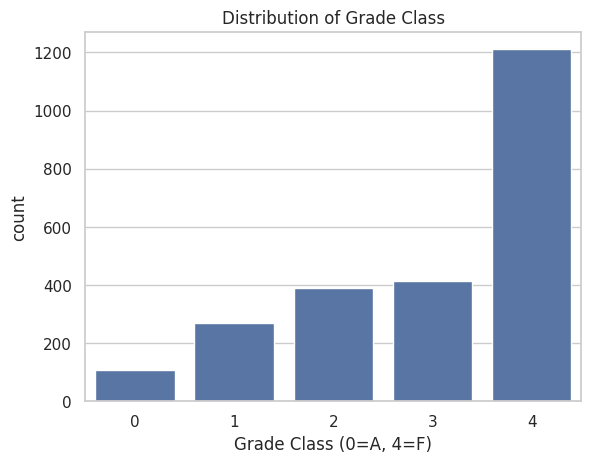

In [130]:
# Target Variable Distribution Plot
sns.countplot(x='GradeClass', data=df)
plt.title("Distribution of Grade Class")
plt.xlabel("Grade Class (0=A, 4=F)")
plt.show()

In [131]:
# Check for any Missing Values
missing_values = df.isnull().sum()

print("Missing Values by Variable:")
print(missing_values)

Missing Values by Variable:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


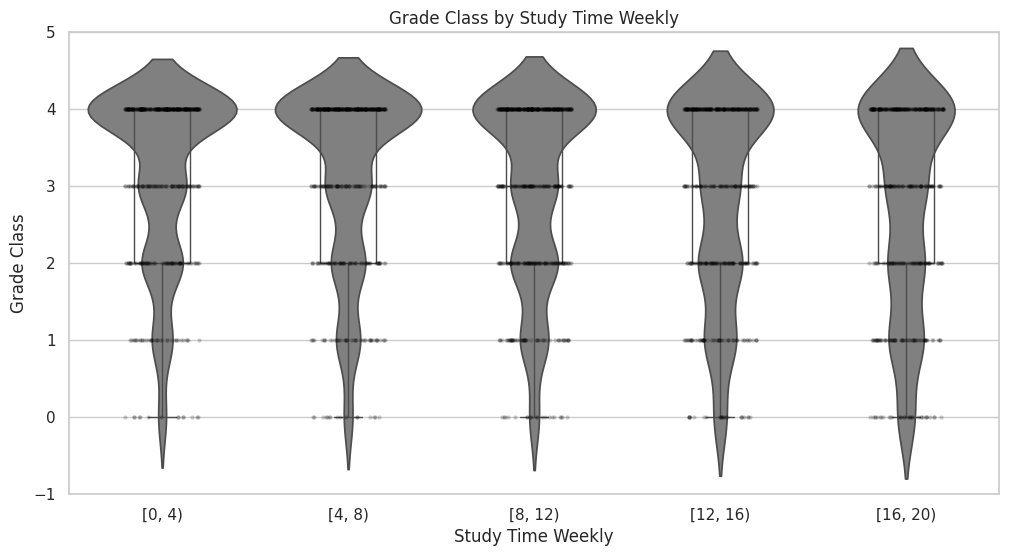

In [132]:
plt.figure(figsize=(12,6))
bin_edges = list(range(0, 21, 4))

df['StudyTimeBin'] = pd.cut(df['StudyTimeWeekly'], bins=bin_edges, include_lowest=True, right=False)
df['StudyTimeBinStr'] = df['StudyTimeBin'].astype(str)
df['StudyTimeBinStr'] = pd.Categorical(df['StudyTimeBinStr'], categories=[str(interval) for interval in df['StudyTimeBin'].cat.categories], ordered=True)
sns.violinplot(x='StudyTimeBinStr', y='GradeClass', data=df, inner=None, color='gray')
sns.boxplot(x='StudyTimeBinStr', y='GradeClass', data=df, showcaps=True, boxprops={'facecolor':'None'}, width=0.3)
sns.stripplot(x='StudyTimeBinStr', y='GradeClass', data=df, color='black', alpha=0.2, jitter=0.2, size=3)

plt.xlabel('Study Time Weekly')
plt.ylabel('Grade Class')
plt.title('Grade Class by Study Time Weekly')
plt.ylim(-1, 5)
plt.show()

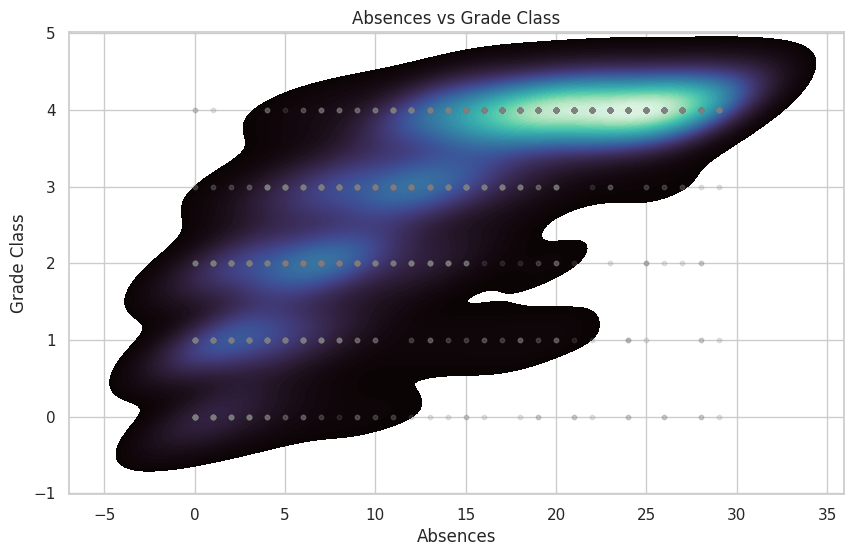

In [133]:
plt.figure(figsize=(10,6))
sns.kdeplot( x=df['Absences'], y=df['GradeClass'], fill=True, thresh=0.03, levels=100, cmap="mako")

plt.scatter(df['Absences'], df['GradeClass'], s=10, alpha=0.2, color='gray')

plt.xlabel('Absences')
plt.ylabel('Grade Class')
plt.title('Absences vs Grade Class')
plt.show()

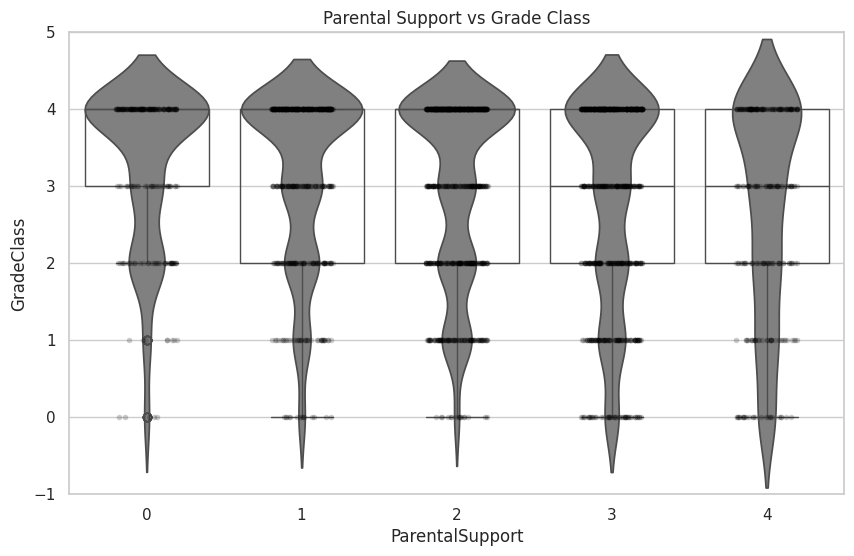

In [134]:

plt.figure(figsize=(10,6))
sns.violinplot(x='ParentalSupport', y='GradeClass', data=df, inner=None, color="gray")
sns.boxplot(x='ParentalSupport', y='GradeClass', data=df, boxprops={'facecolor':'None'})
sns.stripplot(x='ParentalSupport', y='GradeClass', data=df, jitter=0.2, size=4, alpha=0.2, color='black')

plt.ylim(-1,5)
plt.title('Parental Support vs Grade Class')
plt.show()


**Feature Engineering**

In [135]:
# Study efficiency
df['StudyEfficiency'] = df['StudyTimeWeekly'] / (df['Absences'] + 1)

# Combined support
df['SupportIndex'] = df['ParentalSupport'] + df['Tutoring']

# Activity engagement
df['ActivityScore'] = df['Sports'] + df['Music'] + df['Volunteering']

**Data Prepartion**

In [136]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [137]:

X = df.drop(['GradeClass', 'StudentID', 'GPA'], axis=1)
y = df['GradeClass']

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

In [138]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Random Forest**

In [139]:

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.7035490605427975
              precision    recall  f1-score   support

           0       0.29      0.10      0.14        21
           1       0.52      0.56      0.54        54
           2       0.50      0.60      0.55        78
           3       0.48      0.48      0.48        83
           4       0.92      0.90      0.91       243

    accuracy                           0.70       479
   macro avg       0.54      0.53      0.52       479
weighted avg       0.70      0.70      0.70       479



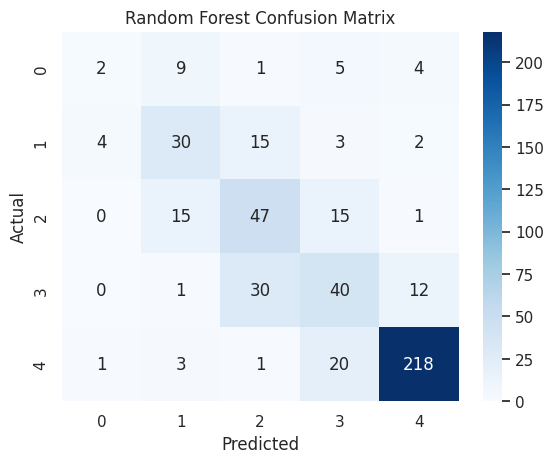

In [140]:
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Random Forest Confusion Matrix")
plt.show()

**Neural Network**

In [141]:

nn = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
nn.fit(X_train, y_train)
nn_preds = nn.predict(X_test)

print("Neural Network Accuracy:", accuracy_score(y_test, nn_preds))
print(classification_report(y_test, nn_preds))

Neural Network Accuracy: 0.6722338204592901
              precision    recall  f1-score   support

           0       0.15      0.14      0.15        21
           1       0.51      0.46      0.49        54
           2       0.52      0.65      0.58        78
           3       0.48      0.46      0.47        83
           4       0.88      0.84      0.86       243

    accuracy                           0.67       479
   macro avg       0.51      0.51      0.51       479
weighted avg       0.68      0.67      0.67       479



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


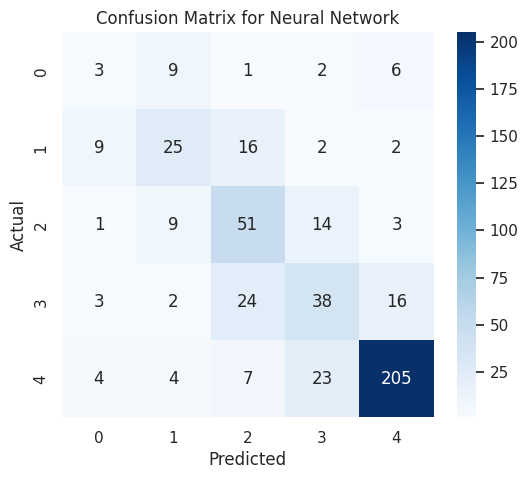

In [142]:
cm = confusion_matrix(y_test, nn_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=True, yticklabels=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Neural Network')
plt.show()

In [143]:
from sklearn.metrics import precision_score, recall_score, f1_score, mean_squared_error, mean_absolute_error
import time
start_rf = time.time()
rf.fit(X_train, y_train)
end_rf = time.time()
rf_time = end_rf - start_rf

start_nn = time.time()
nn.fit(X_train, y_train)
end_nn = time.time()
nn_time = end_nn - start_nn

results = pd.DataFrame({
    "Model": ["Random Forest", "Neural Network"],
    "Accuracy": [accuracy_score(y_test, rf_preds), accuracy_score(y_test, nn_preds)],
    "Precision": [precision_score(y_test, rf_preds, average='weighted'), precision_score(y_test, nn_preds, average='weighted')],
    "Recall": [recall_score(y_test, rf_preds, average='weighted'), recall_score(y_test, nn_preds, average='weighted')],
    "F1 Score": [f1_score(y_test, rf_preds, average='weighted'), f1_score(y_test, nn_preds, average='weighted')],
    "RMSE": [np.sqrt(mean_squared_error(y_test, rf_preds)), np.sqrt(mean_squared_error(y_test, nn_preds))],
    "MAE": [mean_absolute_error(y_test, rf_preds), mean_absolute_error(y_test, nn_preds)],
    "Training Time (s)": [rf_time, nn_time]
})

results


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1 Score,RMSE,MAE,Training Time (s)
0,Random Forest,0.703549,0.702401,0.703549,0.699961,0.814790,0.384134,0.386467
1,Neural Network,0.672234,0.679596,0.672234,0.674158,0.961688,0.469729,4.576286
